# Apple Stock Signal Classifier — Logistic Regression

Predicts whether to **Buy, Sell, or Hold** based on next-day return.
- **Buy**  → next-day return > +0.5%
- **Sell** → next-day return < -0.5%
- **Hold** → next-day return within ±0.5%

Uses walk-forward evaluation — identical setup to the RF notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, ConfusionMatrixDisplay)

plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
df = pd.read_csv('APPLE_daily_reformed.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

for col in ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna().reset_index(drop=True)
print('Rows loaded:', len(df))

Rows loaded: 6638


In [3]:
def add_features(df):
    d = df.copy()
    d['Return_1d']   = d['Close'].pct_change()
    d['Return_2d']   = d['Close'].pct_change(2)
    d['Return_5d']   = d['Close'].pct_change(5)
    d['Return_10d']  = d['Close'].pct_change(10)
    d['Return_20d']  = d['Close'].pct_change(20)

    d['MA_5']  = d['Close'].rolling(5).mean()
    d['MA_20'] = d['Close'].rolling(20).mean()
    d['MA_50'] = d['Close'].rolling(50).mean()
    d['Price_vs_MA5']  = d['Close'] / d['MA_5']  - 1
    d['Price_vs_MA20'] = d['Close'] / d['MA_20'] - 1
    d['Price_vs_MA50'] = d['Close'] / d['MA_50'] - 1
    d['MA5_vs_MA20']   = d['MA_5']  / d['MA_20'] - 1

    delta = d['Close'].diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    d['RSI'] = 100 - 100 / (1 + gain / loss)

    bb_mid = d['Close'].rolling(20).mean()
    bb_std = d['Close'].rolling(20).std()
    d['BB_position'] = (d['Close'] - (bb_mid - 2*bb_std)) / (4 * bb_std)
    d['BB_width']    = (4 * bb_std) / bb_mid

    d['Volatility_10'] = d['Return_1d'].rolling(10).std()
    d['Volatility_20'] = d['Return_1d'].rolling(20).std()
    d['Volume_ratio']  = d['Volume'] / d['Volume'].rolling(20).mean()
    d['High_Low_pct']  = (d['High'] - d['Low']) / d['Close']
    d['Open_Close_pct']= (d['Close'] - d['Open']) / d['Open']
    d['Lag1_return']   = d['Return_1d'].shift(1)
    d['Lag2_return']   = d['Return_1d'].shift(2)
    d['Lag5_return']   = d['Return_1d'].shift(5)
    return d

features = [
    'Return_1d','Return_2d','Return_5d','Return_10d','Return_20d',
    'Price_vs_MA5','Price_vs_MA20','Price_vs_MA50','MA5_vs_MA20',
    'RSI','BB_position','BB_width',
    'Volatility_10','Volatility_20','Volume_ratio',
    'High_Low_pct','Open_Close_pct',
    'Lag1_return','Lag2_return','Lag5_return',
]

THRESHOLD = 0.005  # 0.5% — moves smaller than this are Hold

def label_signal(ret):
    if ret > THRESHOLD:
        return 'Buy'
    elif ret < -THRESHOLD:
        return 'Sell'
    else:
        return 'Hold'

df = add_features(df)
df['Next_Return'] = df['Close'].pct_change().shift(-1)
df['Signal']      = df['Next_Return'].apply(label_signal)
df = df.dropna(subset=features + ['Signal']).reset_index(drop=True)

print(f'{len(df):,} usable rows | {len(features)} features')
print(df['Signal'].value_counts())
print(f'First prediction date: {df["Date"].iloc[256].date()}')


6,589 usable rows | 20 features
Signal
Buy     2622
Sell    2259
Hold    1708
Name: count, dtype: int64
First prediction date: 2001-03-20


In [4]:
window        = 256
retrain_every = 10

X      = df[features].values
y      = df['Signal'].values
dates  = df['Date'].values
closes = df['Close'].values

results = []
model   = None

print(f"Walk-forward: {len(df)-window:,} predictions to make...")

for i in range(window, len(df)):
    step = i - window

    if step % retrain_every == 0:
        model = Pipeline([
            ('scaler', StandardScaler()),
            ('lr', LogisticRegression(
                max_iter=1000,
                class_weight='balanced',  # handles class imbalance
                random_state=42
            )),
        ])
        model.fit(X[i-window:i], y[i-window:i])

        if step % 500 == 0:
            print(f"  Step {step:,}/{len(df)-window:,}  ({step/(len(df)-window)*100:.0f}%)")

    pred_signal = model.predict(X[i].reshape(1, -1))[0]
    pred_proba  = model.predict_proba(X[i].reshape(1, -1))[0]
    classes     = model.classes_

    results.append({
        'Date':        pd.Timestamp(dates[i]),
        'Close':       closes[i],
        'Actual':      y[i],
        'Predicted':   pred_signal,
        **{f'P_{c}': p for c, p in zip(classes, pred_proba)}
    })

res = pd.DataFrame(results)
print(f"\nDone!")
res.tail(8)

Walk-forward: 6,333 predictions to make...
  Step 0/6,333  (0%)
  Step 500/6,333  (8%)
  Step 1,000/6,333  (16%)
  Step 1,500/6,333  (24%)
  Step 2,000/6,333  (32%)
  Step 2,500/6,333  (39%)
  Step 3,000/6,333  (47%)
  Step 3,500/6,333  (55%)
  Step 4,000/6,333  (63%)
  Step 4,500/6,333  (71%)
  Step 5,000/6,333  (79%)
  Step 5,500/6,333  (87%)
  Step 6,000/6,333  (95%)

Done!


,Date,Close,Actual,Predicted,P_Buy,P_Hold,P_Sell
6325,2026-05-14,298.209991,Buy,Sell,0.195327,0.205234,0.599440
6326,2026-05-15,300.230011,Sell,Hold,0.247427,0.405213,0.347359
6327,2026-05-18,297.839996,Hold,Hold,0.166543,0.446489,0.386969
6328,2026-05-19,298.970001,Buy,Sell,0.306525,0.296729,0.396746
6329,2026-05-20,302.250000,Buy,Hold,0.175372,0.512943,0.311685
6330,2026-05-21,304.989990,Buy,Sell,0.300134,0.272532,0.427334
6331,2026-05-22,308.820007,Hold,Buy,0.362834,0.347224,0.289942
6332,2026-05-26,308.329987,Hold,Buy,0.449328,0.222025,0.328647


In [10]:
acc = accuracy_score(res['Actual'], res['Predicted'])
print(f"Overall Accuracy: {acc*100:.2f}%")

                       

Overall Accuracy: 34.20%


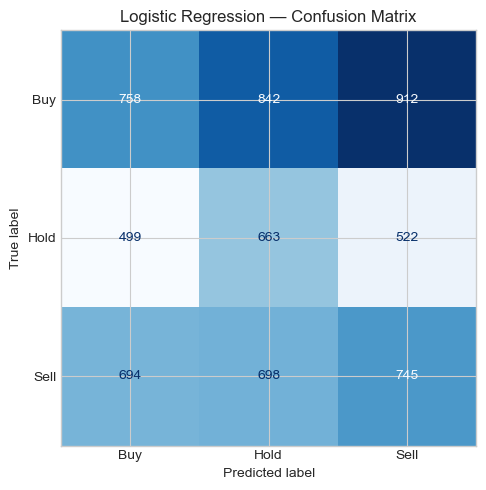

In [6]:
cm = confusion_matrix(res['Actual'], res['Predicted'], labels=['Buy', 'Hold', 'Sell'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Buy', 'Hold', 'Sell'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.show()

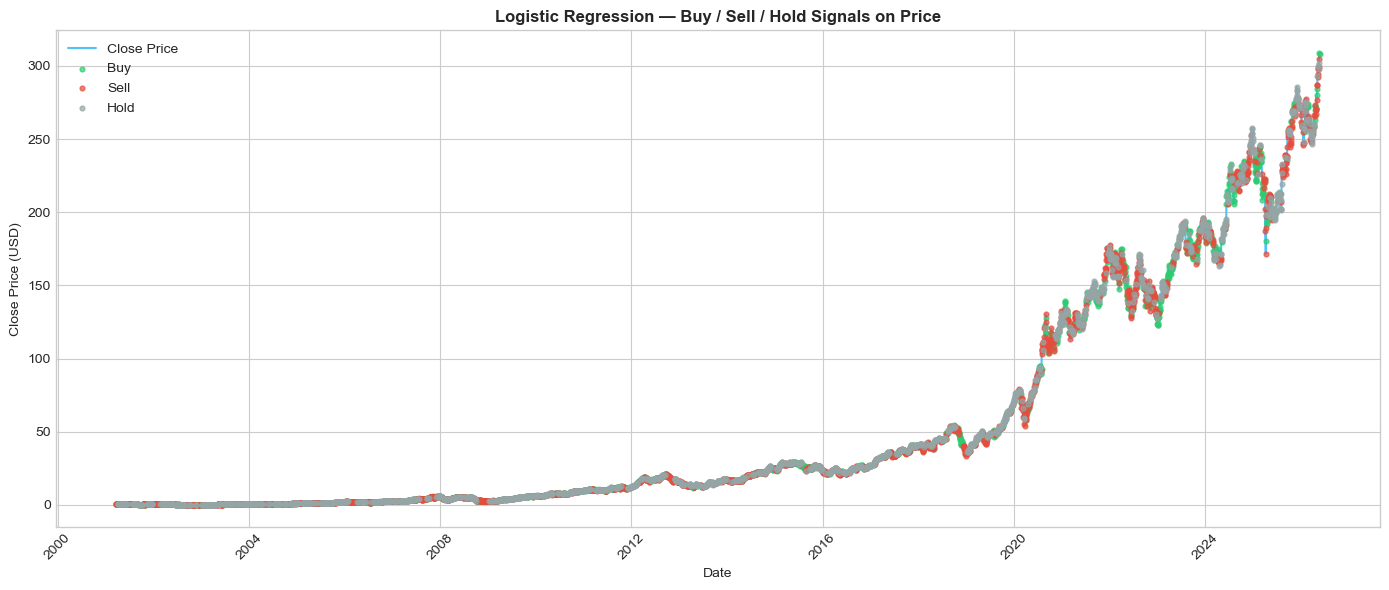

In [7]:
# Plot signals on price chart
color_map = {'Buy': '#2ecc71', 'Sell': '#e74c3c', 'Hold': '#95a5a6'}

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(res['Date'], res['Close'], color='#4fc3f7', linewidth=1.5, label='Close Price', zorder=1)

for signal, color in color_map.items():
    mask = res['Predicted'] == signal
    ax.scatter(res.loc[mask, 'Date'], res.loc[mask, 'Close'],
               color=color, s=12, label=signal, zorder=2, alpha=0.7)

ax.set_title('Logistic Regression — Buy / Sell / Hold Signals on Price', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Close Price (USD)')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
# Next-day signal forecast
X_final = df[features].values[-window:]
y_final = df['Signal'].values[-window:]

model_final = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
])
model_final.fit(X_final, y_final)

latest      = df[features].iloc[[-1]]
pred_signal = model_final.predict(latest)[0]
pred_proba  = model_final.predict_proba(latest)[0]
classes     = model_final.classes_
last_date   = df['Date'].iloc[-1].date()
next_date   = last_date + pd.Timedelta(days=1)

print("=" * 50)
print(f"  NEXT DAY SIGNAL  (from {last_date})")
print(f"  Predicting for:  {next_date}")
print("=" * 50)
print(f"  Signal: {pred_signal}")
print()
print("  Probabilities:")
for c, p in zip(classes, pred_proba):
    print(f"    {c:4s}: {p*100:.1f}%")

  NEXT DAY SIGNAL  (from 2026-05-26)
  Predicting for:  2026-05-27
  Signal: Buy

  Probabilities:
    Buy : 42.6%
    Hold: 28.0%
    Sell: 29.4%


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


## Notes
- Uses `LogisticRegression` with `class_weight='balanced'` to handle the fact that Hold days outnumber Buy/Sell days.
- Walk-forward setup is identical to the RF notebook — same window, same retrain frequency, same features.
- A random classifier would score ~33% accuracy on three classes. Anything meaningfully above 40% on this data is genuine signal.